Dataset Shape: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
Missing Values:

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Duplicate Rows: 0
Columns in Dataset:

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
Data Types:

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


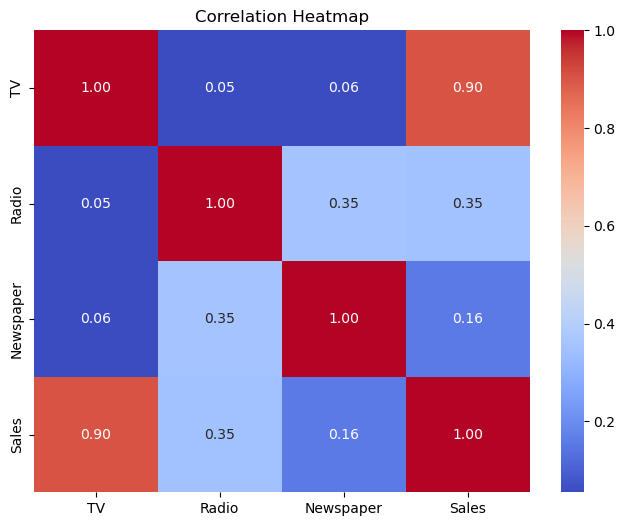

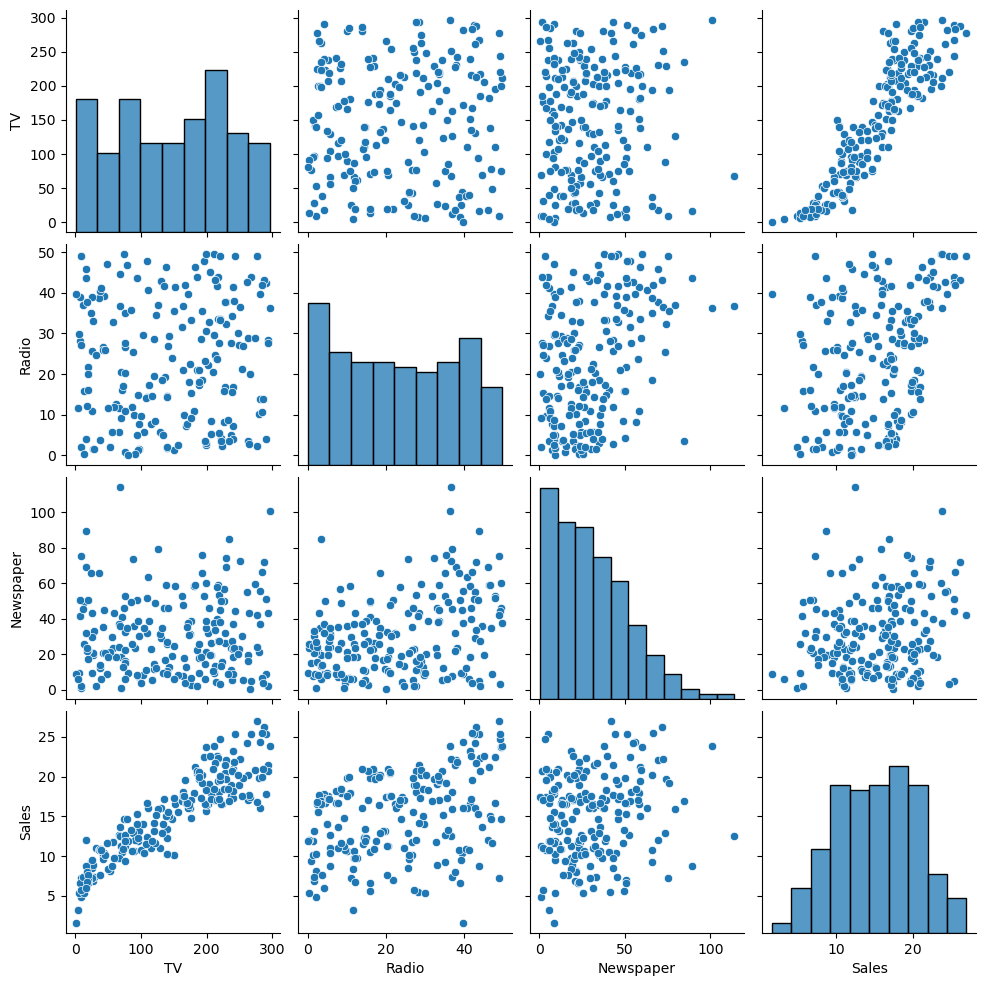

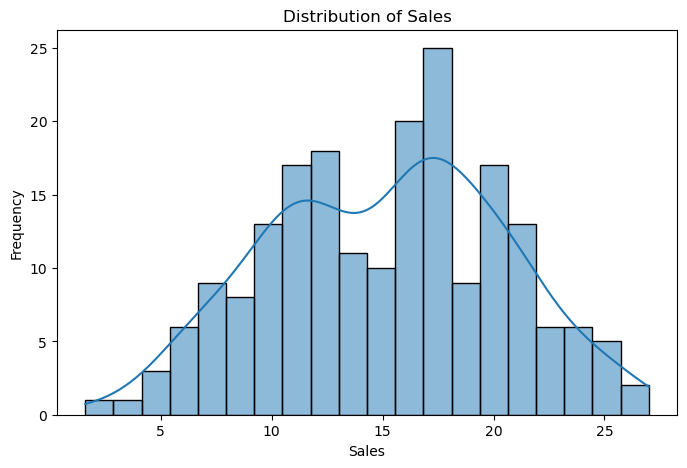

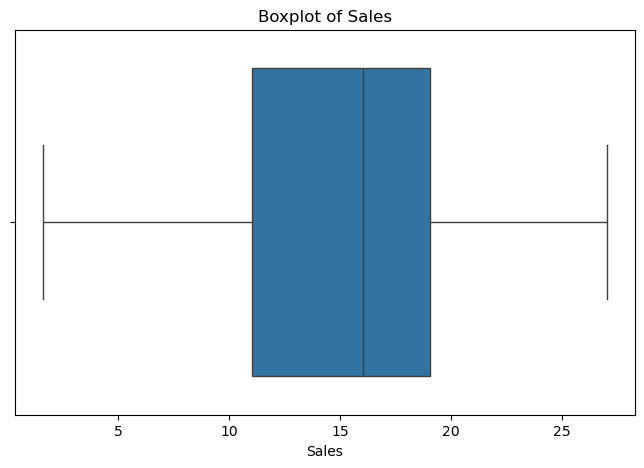

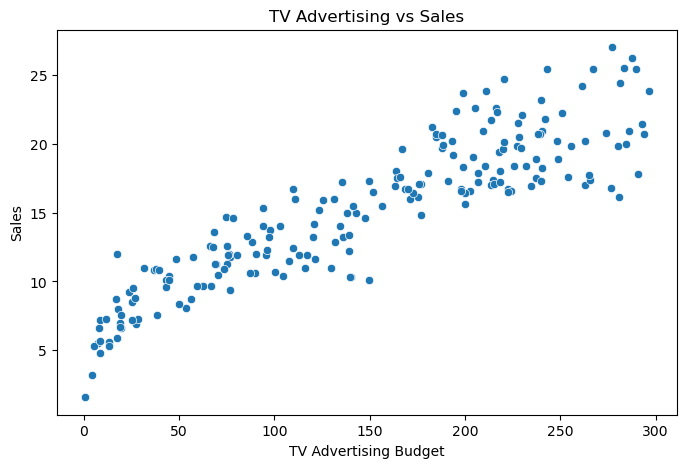

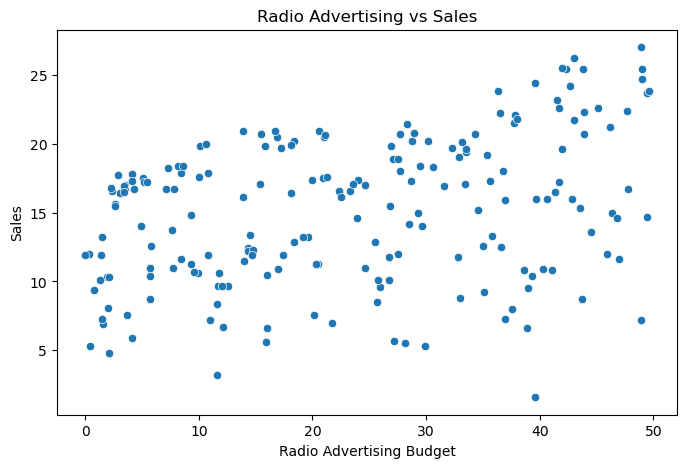

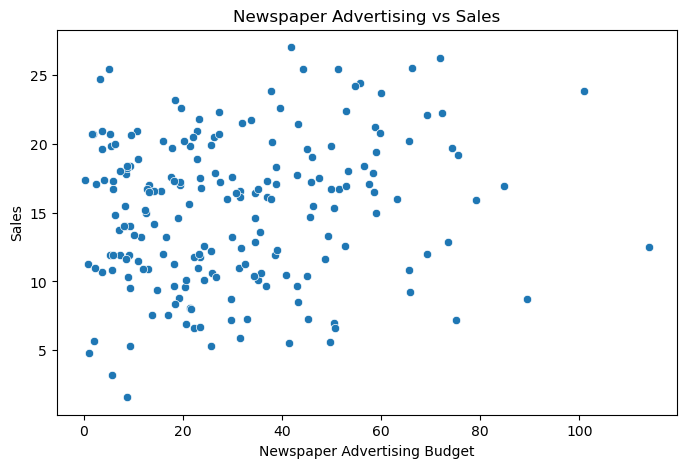

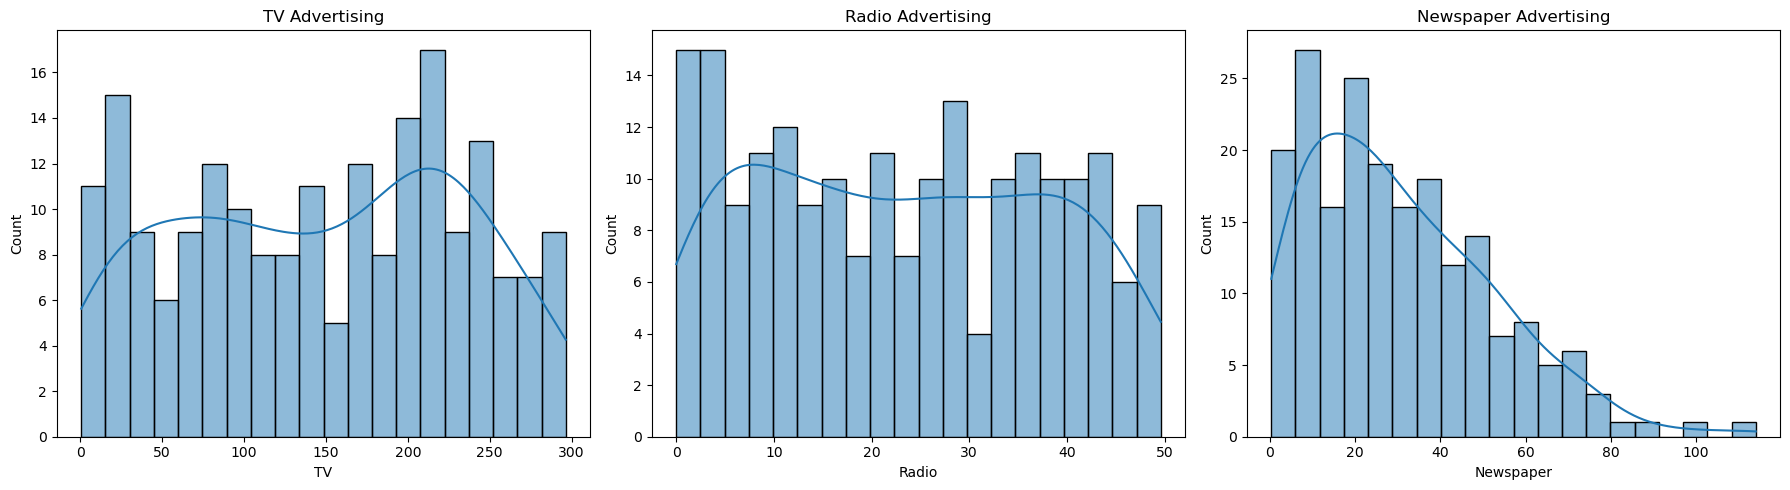

Features (X):
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target (y):
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64
Training Features Shape : (160, 3)
Testing Features Shape  : (40, 3)
Training Target Shape   : (160,)
Testing Target Shape    : (40,)
Model Trained Successfully!
     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337

Intercept: 4.714126402214131
First 10 Predictions:

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]
   Actual Sales  Predicted Sales
0          16.9        17.034772
1          22.4        20.409740
2          21.4        23.723989
3           7.3         9.272785
4          24.7        21.682719
5          12.6        12.569402
6          22.3        21.081195
7           8.4         8.6

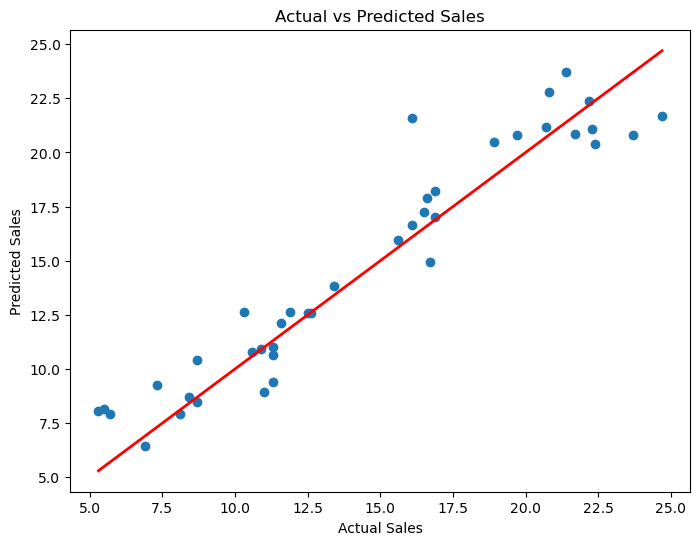

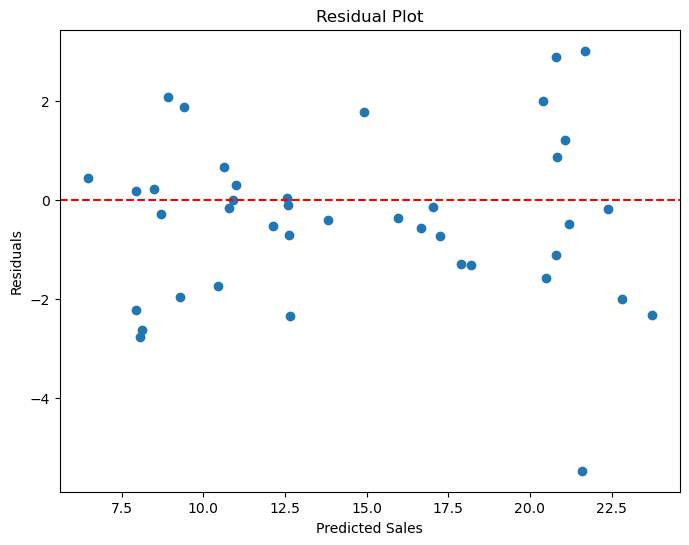

     Feature  Coefficient
1      Radio     0.100945
0         TV     0.054509
2  Newspaper     0.004337


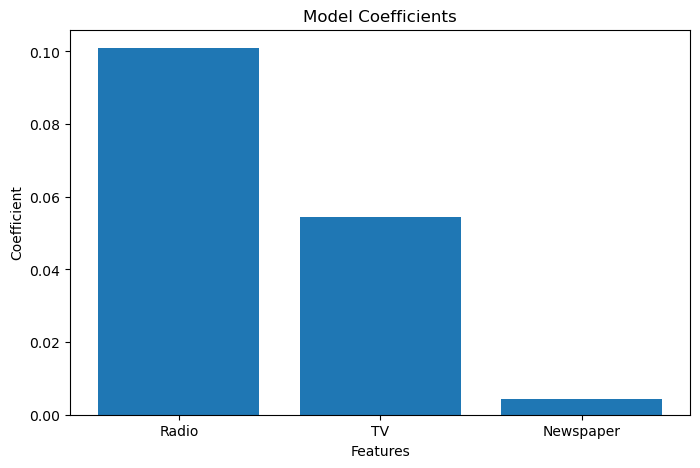

Predicted Sales: 19.32
Model saved successfully!


In [6]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#save the model
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("advertising.csv")

# Display first 5 rows
df.head()

print("Dataset Shape:", df.shape)

df.info()

df.describe()

print("Missing Values:\n")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())
df.tail()

print("Columns in Dataset:\n")
print(df.columns)

print("Data Types:\n")
print(df.dtypes)

#Correlation Matrix
correlation = df.corr()
print(correlation)

#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

#Pairplot
sns.pairplot(df)
plt.show()

#Distribution of Sales
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=20, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

#Boxplot (Outlier Detection)
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sales'])

plt.title("Boxplot of Sales")

plt.show()

#TV vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.show()

#Radio vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.show()

#Newspaper vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.show()

#Advertising Features Distribution
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df['TV'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("TV Advertising")

sns.histplot(df['Radio'], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Radio Advertising")

sns.histplot(df['Newspaper'], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Newspaper Advertising")

plt.tight_layout()
plt.show()

#Feature Selection
# Features (Independent Variables)
X = df[['TV', 'Radio', 'Newspaper']]

# Target Variable (Dependent Variable)
y = df['Sales']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

# Model Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

print("\nIntercept:", model.intercept_)

# Predict Sales
y_pred = model.predict(X_test)

print("First 10 Predictions:\n")
print(y_pred[:10])

comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(comparison.head(10))

# Calculate Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

#Actual vs Predicted Graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

#Residual Plot (Residual = Actual − Predicted)

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(importance['Feature'], importance['Coefficient'])

plt.title("Model Coefficients")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.show()

#Predict Sales for New Data
new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [35],
    'Newspaper': [40]
})

prediction = model.predict(new_data)

print(f"Predicted Sales: {prediction[0]:.2f}")

#Save the Model
joblib.dump(model, "sales_prediction_model.pkl")

print("Model saved successfully!")
